In [4]:
import numpy as np
import matplotlib as mpl
from scipy.optimize import minimize

# Qiskit circuit and parameter tools
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

# Qiskit operators for the Hamiltonian
from qiskit.quantum_info import SparsePauliOp
from qiskit.visualization import array_to_latex

# Modern Qiskit primitive for calculating expectation values
from qiskit.primitives import StatevectorEstimator

In [5]:
# We are simulating the Transverse Field Ising Model
J = 1.0 # Coupling constant
h = 0.5 # External field

H = SparsePauliOp.from_list([
    ("ZZ", -J),  # Spin interaction between Qubit 1 and Qubit 0
    ("XI", -h),  # Transverse field acting on Qubit 1
    ("IX", -h)   # Transverse field acting on Qubit 0
])

array_to_latex(H.to_matrix(), prefix="H = ")

<IPython.core.display.Latex object>

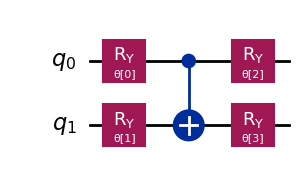

In [20]:
# Implement the ansatz

# Four parameters for a 4D space
params = ParameterVector('θ', 4)    

#Initial rotation
ansatz = QuantumCircuit(2)
ansatz.ry(params[0], 0)
ansatz.ry(params[1], 1)

#Entangle the qubits
ansatz.cx(0, 1)

# Final rotations on both qubits
ansatz.ry(params[2], 0)
ansatz.ry(params[3], 1)

ansatz.draw('mpl')

In [21]:
estimator = StatevectorEstimator()

def cost_function(param_values):
    """
    Evaluates the energy of the ansatz for given parameter values.
    param_values: an array of parameter values provided by the optimizer.
    """
    # Bundle the circuit, observable, and parameter value into a PUB
    pub = (ansatz, H, param_values)
    
    # Run the estimator
    job = estimator.run([pub])
    
    # Extract the result
    result = job.result()
    energy = result[0].data.evs
    
    return float(energy)

In [22]:
# Define a starting point (initial guess)
# Since we have 1 parameter, we provide an array with 1 initial value
initial_guess = [0.0, 0.0, 0.0, 0.0]

# Run the optimizer
result = minimize(
    fun=cost_function,      # The objective function to minimize
    x0=initial_guess,       # The initial guess for the parameters
    method='COBYLA',        # The optimization algorithm
    options={'maxiter': 1000} # Number of iterations
)

# Extract the results
optimal_thetas = result.x
minimum_energy = result.fun

print(f"Optimization converged: {result.success}")
print(f"Optimal Thetas: {np.round(optimal_thetas, 4)} radians")
print(f"Calculated Ground State Energy: {minimum_energy:.4f}")

Optimization converged: True
Optimal Thetas: [1.1227 0.6688 0.659  0.5009] radians
Calculated Ground State Energy: -1.4142


In [23]:
num_starts = 100 
global_best_energy = float('inf') 
global_best_thetas = None
best_result_object = None

for i in range(num_starts):
    # Generate an array of 4 random initial guesses between 0 and 2*pi
    random_guess = np.random.uniform(0, 2 * np.pi, size=4)
    
    # Run the optimizer
    result = minimize(
        fun=cost_function,
        x0=random_guess,
        method='COBYLA',
        options={'maxiter': 1000}
    )
    
    # Evaluate the global minimum
    if result.fun < global_best_energy:
        global_best_energy = result.fun
        global_best_thetas = result.x
        best_result_object = result

print("\n--- Global Optimization Complete ---")
print(f"Optimization converged: {best_result_object.success}")
print(f"Global Optimal Thetas: {np.round(global_best_thetas, 4)} radians")
print(f"Calculated Ground State Energy: {global_best_energy:.4f}")


--- Global Optimization Complete ---
Optimization converged: True
Global Optimal Thetas: [4.1722 3.7431 5.4688 2.4985] radians
Calculated Ground State Energy: -1.4142
